In [1]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity

# ============================================================
# Single-site field operators from ladder operators
# ============================================================

def single_site_field_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Local Hilbert dimension
    # -------------------------------------------------------- kjacvbnm,./qwertyuiopp//÷//

 
    Nphi = 2**nq   # 64 for nq=6

    # --------------------------------------------------------
    # Ladder operator a
    # --------------------------------------------------------

    a = np.zeros((Nphi, Nphi), dtype=complex)

    for n in range(1, Nphi):

        a[n-1, n] = np.sqrt(n)

    # creation operator
    adag = a.conj().T

    # --------------------------------------------------------
    # Field operator
    #
    # Phi = (a + adag)/sqrt(2 mu)
    # --------------------------------------------------------

    Phi = (
        a + adag
    ) / np.sqrt(2 * mu)

    # --------------------------------------------------------
    # Conjugate momentum operator
    #
    # Pi = -i sqrt(mu/2) (a - adag)
    # --------------------------------------------------------

    Pi = (
        -1j
        * np.sqrt(mu / 2)
        * (a - adag)
    )

    # --------------------------------------------------------
    # Numerical Hermiticity cleanup
    # --------------------------------------------------------

    Phi = 0.5 * (Phi + Phi.conj().T)

    Pi = 0.5 * (Pi + Pi.conj().T)

    return csr_matrix(Phi), csr_matrix(Pi)


# ============================================================
# Two-site embedded operators
# ============================================================

def two_site_operators(nq, mu=1.0):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(
        Nphi,
        format='csr',
        dtype=complex
    )

    # --------------------------------------------------------
    # Site 0 operators
    # --------------------------------------------------------

    Phi0 = kron(Phi, I, format='csr')
    Pi0  = kron(Pi,  I, format='csr')

    # --------------------------------------------------------
    # Site 1 operators
    # --------------------------------------------------------

    Phi1 = kron(I, Phi, format='csr')
    Pi1  = kron(I, Pi,  format='csr')

    return Phi0, Pi0, Phi1, Pi1


# ============================================================
# Example
# ============================================================

nq = 4
mu = 1.0

Phi0, Pi0, Phi1, Pi1 = two_site_operators(
    nq,
    mu
)

print("Hilbert dimension =", Phi0.shape[0])

print("Phi0 shape =", Phi0.shape)
print("Pi0 shape  =", Pi0.shape)

print("Phi1 shape =", Phi1.shape)
print("Pi1 shape  =", Pi1.shape)

Hilbert dimension = 256
Phi0 shape = (256, 256)
Pi0 shape  = (256, 256)
Phi1 shape = (256, 256)
Pi1 shape  = (256, 256)


In [2]:
import numpy as np
from scipy.sparse import csr_matrix, kron, identity
from scipy.sparse.linalg import eigsh

# ============================================================
# Local single-site Hamiltonian
# ============================================================

def single_site_hloc(Phi, Pi, mI2, lam, f):

    Phi2 = Phi @ Phi
    Phi4 = Phi2 @ Phi2
    Pi2  = Pi @ Pi

    hloc = (
        0.5 * Pi2
        + 0.5 * mI2 * Phi2
        + (lam / 24.0) * Phi4
        + f * Phi
    )

    return hloc




In [3]:
# ============================================================
# Two-site local Hamiltonian
# ============================================================

def two_site_hloc(nq, mu=1.0,
                  mI2=1.0,
                  lam=1.0,
                  f=1e-3):

    # --------------------------------------------------------
    # Single-site operators
    # --------------------------------------------------------

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    # --------------------------------------------------------
    # Single-site local Hamiltonian
    # --------------------------------------------------------

    hloc = single_site_hloc(Phi, Pi, mI2, lam, f)

    # --------------------------------------------------------
    # Two-site Hamiltonian
    # H = h ⊗ I + I ⊗ h
    # --------------------------------------------------------

    Hloc = (
        kron(hloc, I, format='csr')
        +
        kron(I, hloc, format='csr')
    )

    return Hloc




In [4]:
# ============================================================
# Exact ground state
# ============================================================

def ground_state(H):

    # smallest algebraic eigenvalue
    evals, evecs = eigsh(H, k=1, which='SA')

    E0 = evals[0]
    psi0 = evecs[:, 0]

    # normalize explicitly
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0




In [5]:
# ============================================================
# Example
# ============================================================

nq   = 4
mu   = 1.0
mI2  = 1.0
lam  = 1.0
f    = 1e-5

Hloc = two_site_hloc(
    nq=nq,
    mu=mu,
    mI2=mI2,
    lam=lam,
    f=f
)

E0_loc, psi_loc = ground_state(Hloc)

print("Ground-state energy =", E0_loc)
print("State dimension     =", psi_loc.shape)
print("Norm                =", np.linalg.norm(psi_loc))

Ground-state energy = 1.0554722545756816
State dimension     = (256,)
Norm                = 1.0


In [6]:
# ============================================================
# Convert scalar-field Hamiltonian to Pauli form

# ============================================================

from qiskit.quantum_info import Operator, SparsePauliOp

# ============================================================
# Build two-site Hamiltonian
# ============================================================

Hloc = two_site_hloc(
    nq=4,
    mu=1.0,
    mI2=1.0,
    lam=1.0,
    f=1e-5
)

# ============================================================
# Convert sparse matrix -> dense matrix
# ============================================================

H_dense = Hloc.toarray()

print("Dense Hamiltonian shape =", H_dense.shape)

# ============================================================
# Convert to Qiskit Operator
# ============================================================

H_op = Operator(H_dense)

# ============================================================
# Convert to SparsePauliOp
# ============================================================

print("\nConverting to Pauli representation...\n")

H_pauli = SparsePauliOp.from_operator(H_op)

# ============================================================
# Remove tiny coefficients
# ============================================================

H_pauli = H_pauli.simplify(atol=1e-10)

print("Done.")

# ============================================================
# Number of Pauli terms
# ============================================================

print("\nNumber of Pauli terms =", len(H_pauli))

# ============================================================
# Show first few Pauli terms
# ============================================================

print("\nFirst few Pauli terms:\n")

for pauli, coeff in zip(
    H_pauli.paulis[:10],
    H_pauli.coeffs[:10]
):

    print(f"{coeff:.6f} * {pauli}")

Dense Hamiltonian shape = (256, 256)

Converting to Pauli representation...

Done.

Number of Pauli terms = 111

First few Pauli terms:

24.062500+0.000000j * IIIIIIII
0.000019+0.000000j * IIIIIIIX
3.203275+0.000000j * IIIIIIXI
-0.031443+0.000000j * IIIIIIXZ
-0.687500+0.000000j * IIIIIIZI
-0.937500+0.000000j * IIIIIIZZ
0.833067+0.000000j * IIIIIXII
-0.083419+0.000000j * IIIIIXIZ
1.669265+0.000000j * IIIIIXXI
-0.166668+0.000000j * IIIIIXXZ


In [7]:
# ============================================================
# Remove identity offset
# ============================================================

coeffs = H_pauli.coeffs
paulis = H_pauli.paulis

new_coeffs = []
new_paulis = []

identity_shift = 0.0

for p, c in zip(paulis, coeffs):

    if str(p) == 'I' * nq:

        identity_shift += np.real(c)

    else:

        new_paulis.append(p)
        new_coeffs.append(c)

H_pauli_shifted = SparsePauliOp(
    new_paulis,
    coeffs=new_coeffs
)

print("Removed identity shift =", identity_shift)

print("Remaining Pauli terms =",
      len(H_pauli_shifted))

Removed identity shift = 0.0
Remaining Pauli terms = 111


In [9]:
###### Exact Ground State Utility

# ============================================================
# Exact ground state from sparse Hamiltonian
# ============================================================

from scipy.sparse.linalg import eigsh


def exact_ground_state(H_sparse):

    evals, evecs = eigsh(H_sparse, k=1, which='SA')

    E0 = np.real(evals[0])

    psi0 = evecs[:, 0]
    psi0 = psi0 / np.linalg.norm(psi0)

    return E0, psi0


In [10]:
nq_site = 4

nqubits = 2 * nq_site

mu = 1.0

layers = 8



# ============================================================
# Parameter sets
# ============================================================

parameter_sets = [

    {
        "label": "Symmetric",
        "mI2": 1.0,
        "f": 0.0
    },

    {
        "label": "Weak SSB",
        "mI2": -1.0,
        "f": 1e-5
    },
    
    {
        "label": "Weak SSB optimised",
        "mI2": -1.0,
        "f": 5*1e-2
    },
   {
        "label": "Strong SSB",
        "mI2": -1.0,
        "f": 0.5
    }
]

# ============================================================
# Lambda scan
# ============================================================

lambda_list = np.linspace(0.1, 2.0, 10)

all_results = []
    
   
    

In [11]:
# ============================================================
# H_c
# ============================================================

def two_site_hc(

    nq,

    mu=1.0,

    m0_sq=1.0,

    mI2=1.0
):

    Phi, Pi = single_site_field_operators(nq, mu)

    Nphi = 2**nq

    I = identity(Nphi, format='csr', dtype=complex)

    Phi0 = kron(Phi, I, format='csr')

    Phi1 = kron(I, Phi, format='csr')

    Hc = (

        0.5 * (
            (Phi1 - Phi0) @ (Phi1 - Phi0)
        )

        +

        0.5 * (m0_sq - mI2) * (

            (Phi0 @ Phi0)

            +

            (Phi1 @ Phi1)
        )
    )

    return Hc


In [12]:
# ============================================================
# H_s
# ============================================================

def two_site_hs(

    nq,

    mu=1.0,

    mI2=1.0,

    m0_sq=1.0,

    lam=1.0,

    f=0.0,

    s=1.0
):

    Hloc = two_site_hloc(

        nq=nq,

        mu=mu,

        mI2=mI2,

        lam=lam,

        f=f
    )

    Hc = two_site_hc(

        nq=nq,

        mu=mu,

        m0_sq=m0_sq,

        mI2=mI2
    )

    return Hloc + s * Hc


In [13]:
# ============================================================
# Exact ground state
# ============================================================

def exact_ground_state(H):

    H_dense = H.toarray()

    eigvals, eigvecs = np.linalg.eigh(H_dense)

    return eigvals[0], eigvecs[:, 0]

In [14]:
# ============================================================
# Minimum instantaneous gap along adiabatic path
# ============================================================

def minimum_gap_along_path(

    nq,

    mu,

    mI2,

    m0_sq,

    lam,

    f,

    nsteps=100
):

    gap_min = 1e100

    for step in range(nsteps):

        s = step / nsteps

        Hs = two_site_hs(

            nq=nq,

            mu=mu,

            mI2=mI2,

            m0_sq=m0_sq,

            lam=lam,

            f=f,

            s=s
        )

        evals, _ = eigsh(

            Hs,

            k=2,

            which='SA'
        )

        evals = np.sort(np.real(evals))

        gap = evals[1] - evals[0]

        gap_min = min(gap_min, gap)

    return gap_min

In [15]:



# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================
for params in parameter_sets:
    for lam in lambda_list:
    
        label = params["label"]
        mI2 = params["mI2"]
        f = params["f"]
        
    
        Hs_final = two_site_hs(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            s=1.0
        )

        E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
        )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

        delta_min = minimum_gap_along_path(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        print(f"Minimum path gap = {delta_min:.8e}")

   

       
    
        evals, evecs = eigsh(

                Hs_final,

                k=3,

                which='SA'
            )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

    
        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
    

    # ========================================================
    # Store
    # ========================================================

        adiabatic_results.append({

            'case': label,
            'lambda': lam,
            'mI2': mI2,
            'f': f,

    
            'delta_min': delta_min,

        

            'final_gap': final_gap,
            'psi_exact_final': psi_exact_final
        })

   

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    
    f"{'Delta_min':<18}"
    
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        
        f"{r['delta_min']:<18.8e}"
        
    )

Minimum path gap = 1.00972087e+00
E1-E0  = 1.00970921e+00
Minimum path gap = 1.02934439e+00
E1-E0  = 1.02931057e+00
Minimum path gap = 1.04790824e+00
E1-E0  = 1.04785498e+00
Minimum path gap = 1.06556366e+00
E1-E0  = 1.06549312e+00
Minimum path gap = 1.08242773e+00
E1-E0  = 1.08234168e+00
Minimum path gap = 1.09859358e+00
E1-E0  = 1.09849351e+00
Minimum path gap = 1.11413694e+00
E1-E0  = 1.11402410e+00
Minimum path gap = 1.12912045e+00
E1-E0  = 1.12899591e+00
Minimum path gap = 1.14359670e+00
E1-E0  = 1.14346139e+00
Minimum path gap = 1.15761039e+00
E1-E0  = 1.15746513e+00
Minimum path gap = 3.13498607e-04
E1-E0  = 1.00970921e+00
Minimum path gap = 1.22564919e-04
E1-E0  = 1.02931057e+00
Minimum path gap = 1.14483174e-04
E1-E0  = 1.04785498e+00
Minimum path gap = 2.21982966e-04
E1-E0  = 1.06549312e+00
Minimum path gap = 4.33063144e-03
E1-E0  = 1.08234168e+00
Minimum path gap = 2.50115281e-02
E1-E0  = 1.09849351e+00
Minimum path gap = 6.77198754e-02
E1-E0  = 1.11402410e+00
Minimum path g

In [16]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=1.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=1.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=1.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.1000
Weak SSB opt    λc = 0.1000
Strong SSB      λc = 0.1000


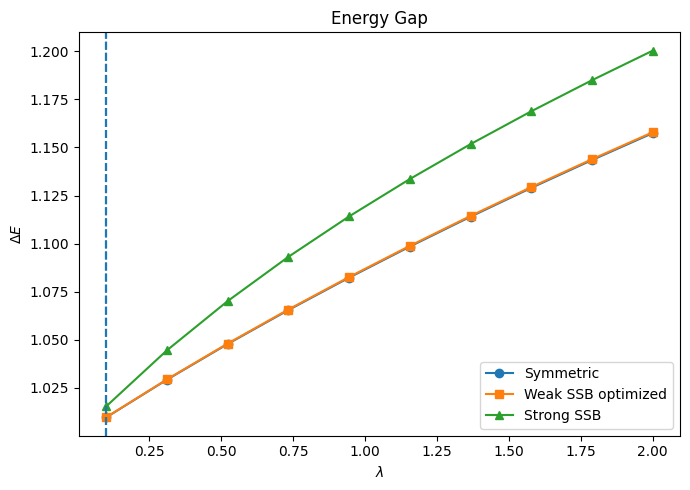

In [17]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimized')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title('Energy Gap')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Order parameter operator
# ============================================================

Phi0, Pi0, Phi1, Pi1 = two_site_operators(

    nq_site,

    mu
)

Phi_avg = 0.5 * (Phi0 + Phi1)

In [19]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    mI2 = r['mI2']

    f = r['f']
    psi_exact_final=r['psi_exact_final']
    

    M = np.real(

        np.vdot(

            psi_exact_final,

            Phi_avg @ psi_exact_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

dict_keys(['case', 'lambda', 'mI2', 'f', 'delta_min', 'final_gap', 'psi_exact_final'])


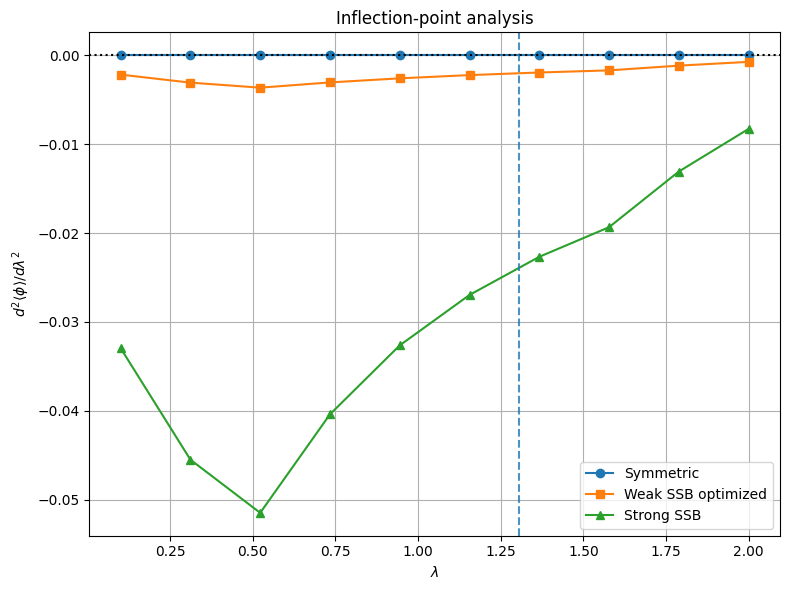

In [20]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_list)

dM_weak = np.gradient(M_weak_opt, lambda_list)

dM_strong = np.gradient(M_strong, lambda_list)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_list)

d2M_weak = np.gradient(dM_weak, lambda_list)

d2M_strong = np.gradient(dM_strong, lambda_list)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_list)

d3M_weak = np.gradient(d2M_weak, lambda_list)

d3M_strong = np.gradient(d2M_strong, lambda_list)


def find_lambda_c(lams, d2M, d3M):

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            if d3M[i] < 0:

                x1 = lams[i]
                x2 = lams[i+1]

                y1 = d2M[i]
                y2 = d2M[i+1]

                return x1 - y1*(x2-x1)/(y2-y1)

    return np.nan

lamc_M_sym = find_lambda_c(
    lambda_list,
    d2M_sym,
    d3M_sym
)

lamc_M_weak = find_lambda_c(
    lambda_list,
    d2M_weak,
    d3M_weak
)

lamc_M_strong = find_lambda_c(
    lambda_list,
    d2M_strong,
    d3M_strong
)


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

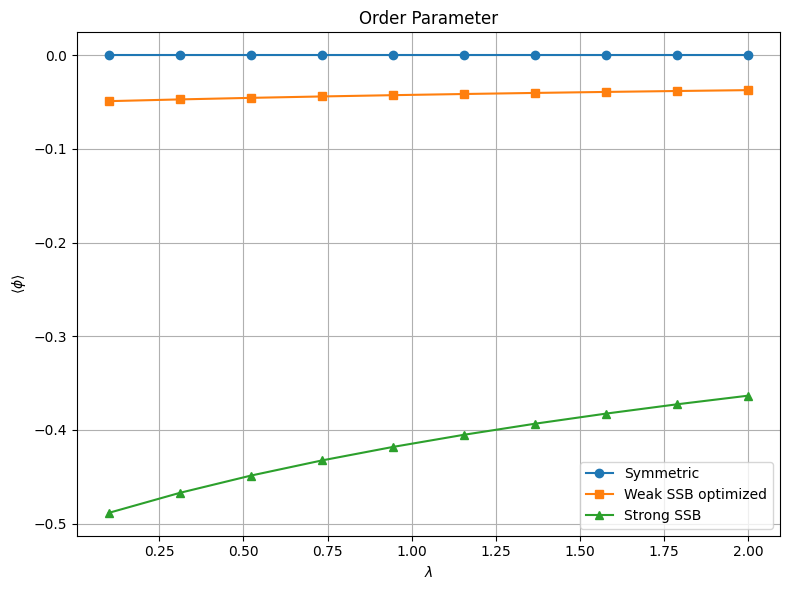

In [21]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_list,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_list,

    M_weak_opt,

    's-',

    label='Weak SSB optimized'
)

plt.plot(

    lambda_list,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title('Order Parameter')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

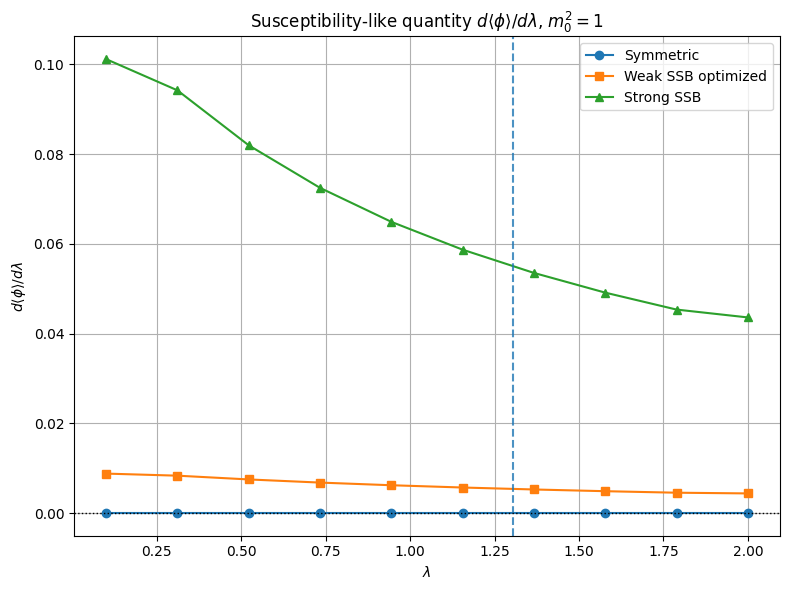

In [22]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_0^2=1$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Starting of m0^2=2

In [42]:



# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================
for params in parameter_sets:
    for lam in lambda_list:
    
        label = params["label"]
        mI2 = params["mI2"]
        f = params["f"]
        
    
        Hs_final = two_site_hs(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=2.0,

            lam=lam,

            f=f,

            s=1.0
        )

        E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
        )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

        delta_min = minimum_gap_along_path(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        print(f"Minimum path gap = {delta_min:.8e}")

   

       
    
        evals, evecs = eigsh(

                Hs_final,

                k=3,

                which='SA'
            )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

    
        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
    

    # ========================================================
    # Store
    # ========================================================

        adiabatic_results.append({

            'case': label,
            'lambda': lam,
            'mI2': mI2,
            'f': f,

    
            'delta_min': delta_min,

        

            'final_gap': final_gap,
            'psi_exact_final': psi_exact_final
        })

   

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    
    f"{'Delta_min':<18}"
    
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        
        f"{r['delta_min']:<18.8e}"
        
    )

Minimum path gap = 1.01220263e+00
E1-E0  = 1.41951501e+00
Minimum path gap = 1.03626623e+00
E1-E0  = 1.43049943e+00
Minimum path gap = 1.05846299e+00
E1-E0  = 1.44121779e+00
Minimum path gap = 1.07916278e+00
E1-E0  = 1.45168821e+00
Minimum path gap = 1.09862393e+00
E1-E0  = 1.46192674e+00
Minimum path gap = 1.11703633e+00
E1-E0  = 1.47194767e+00
Minimum path gap = 1.13454489e+00
E1-E0  = 1.48176382e+00
Minimum path gap = 1.15126343e+00
E1-E0  = 1.49138674e+00
Minimum path gap = 1.16728342e+00
E1-E0  = 1.50082688e+00
Minimum path gap = 1.18267976e+00
E1-E0  = 1.51009377e+00
Minimum path gap = 4.00578748e-04
E1-E0  = 1.41951501e+00
Minimum path gap = 1.22897118e-04
E1-E0  = 1.43049943e+00
Minimum path gap = 1.15176142e-04
E1-E0  = 1.44121779e+00
Minimum path gap = 2.97449186e-04
E1-E0  = 1.45168821e+00
Minimum path gap = 5.82831771e-03
E1-E0  = 1.46192674e+00
Minimum path gap = 3.15665395e-02
E1-E0  = 1.47194767e+00
Minimum path gap = 7.80721241e-02
E1-E0  = 1.48176382e+00
Minimum path g

In [43]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=2.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=2.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=2.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.1000
Weak SSB opt    λc = 0.1000
Strong SSB      λc = 0.1000


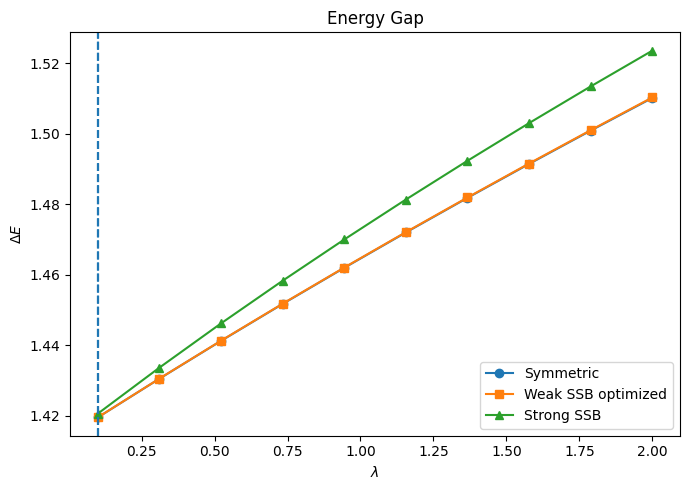

In [44]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimized')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title('Energy Gap')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# Order parameter operator
# ============================================================

Phi0, Pi0, Phi1, Pi1 = two_site_operators(

    nq_site,

    mu
)

Phi_avg = 0.5 * (Phi0 + Phi1)

In [46]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    mI2 = r['mI2']

    f = r['f']
    psi_exact_final=r['psi_exact_final']
    

    M = np.real(

        np.vdot(

            psi_exact_final,

            Phi_avg @ psi_exact_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

dict_keys(['case', 'lambda', 'mI2', 'f', 'delta_min', 'final_gap', 'psi_exact_final'])


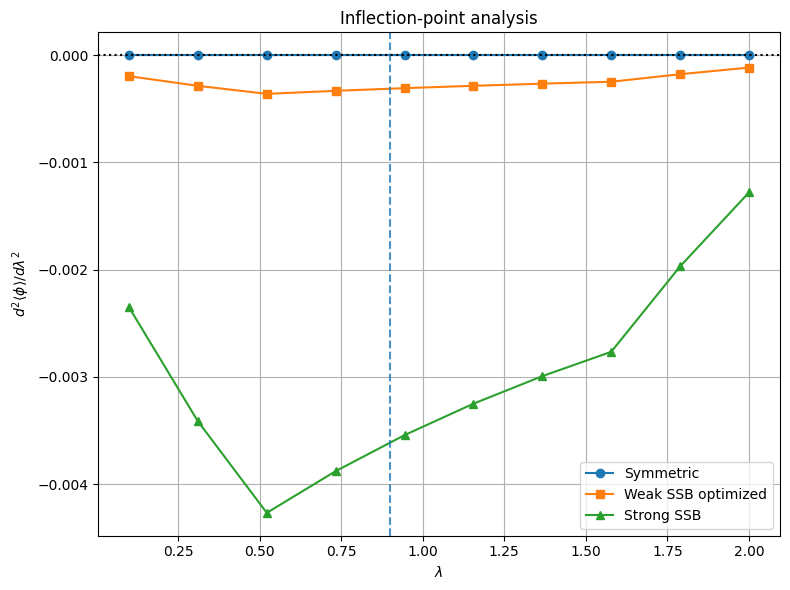

In [47]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_list)

dM_weak = np.gradient(M_weak_opt, lambda_list)

dM_strong = np.gradient(M_strong, lambda_list)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_list)

d2M_weak = np.gradient(dM_weak, lambda_list)

d2M_strong = np.gradient(dM_strong, lambda_list)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_list)

d3M_weak = np.gradient(d2M_weak, lambda_list)

d3M_strong = np.gradient(d2M_strong, lambda_list)


def find_lambda_c(lams, d2M, d3M):

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            if d3M[i] < 0:

                x1 = lams[i]
                x2 = lams[i+1]

                y1 = d2M[i]
                y2 = d2M[i+1]

                return x1 - y1*(x2-x1)/(y2-y1)

    return np.nan

lamc_M_sym = find_lambda_c(
    lambda_list,
    d2M_sym,
    d3M_sym
)

lamc_M_weak = find_lambda_c(
    lambda_list,
    d2M_weak,
    d3M_weak
)

lamc_M_strong = find_lambda_c(
    lambda_list,
    d2M_strong,
    d3M_strong
)


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

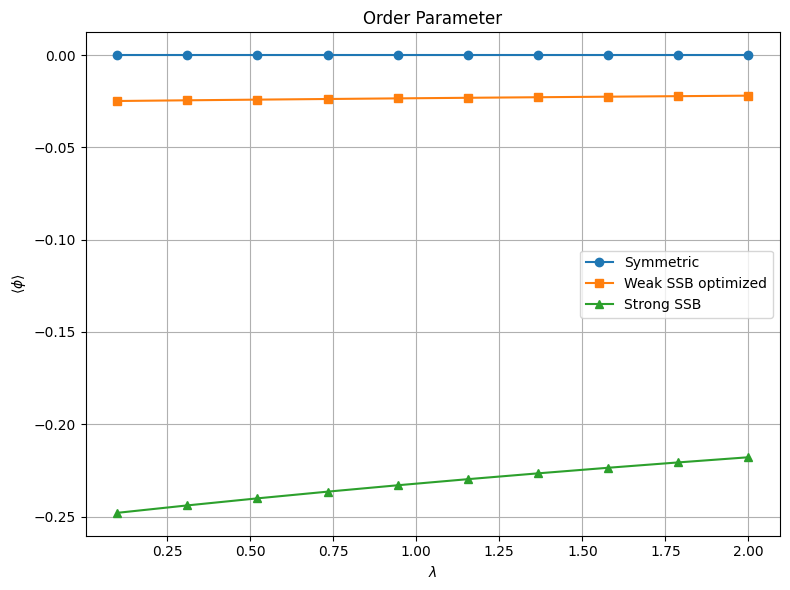

In [48]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_list,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_list,

    M_weak_opt,

    's-',

    label='Weak SSB optimized'
)

plt.plot(

    lambda_list,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title('Order Parameter')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

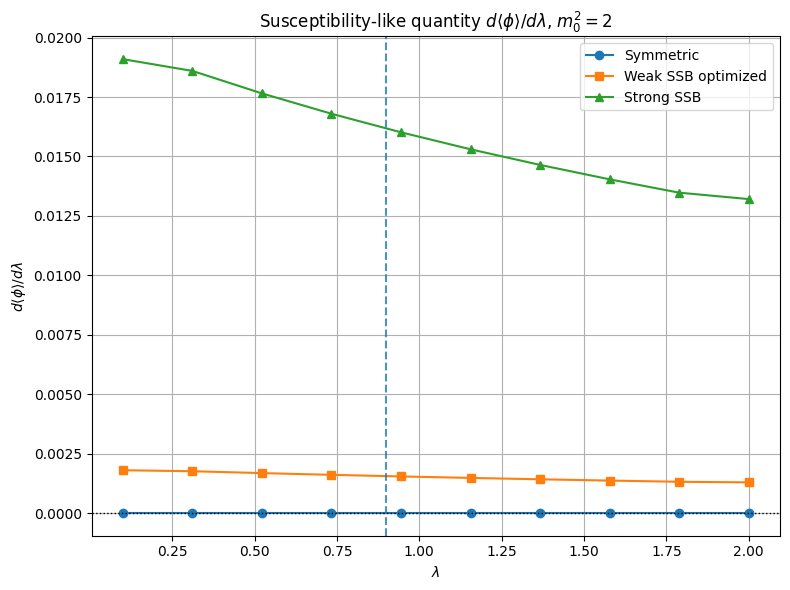

In [49]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_0^2=2$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Start of m0^2=-1.0

In [35]:



# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================
for params in parameter_sets:
    for lam in lambda_list:
    
        label = params["label"]
        mI2 = params["mI2"]
        f = params["f"]
        
    
        Hs_final = two_site_hs(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=-1.0,

            lam=lam,

            f=f,

            s=1.0
        )

        E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
        )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

        delta_min = minimum_gap_along_path(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=-1.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        print(f"Minimum path gap = {delta_min:.8e}")

   

       
    
        evals, evecs = eigsh(

                Hs_final,

                k=3,

                which='SA'
            )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

    
        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
    

    # ========================================================
    # Store
    # ========================================================

        adiabatic_results.append({

            'case': label,
            'lambda': lam,
            'mI2': mI2,
            'f': f,

    
            'delta_min': delta_min,

        

            'final_gap': final_gap,
            'psi_exact_final': psi_exact_final
        })

   

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    
    f"{'Delta_min':<18}"
    
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        
        f"{r['delta_min']:<18.8e}"
        
    )

Minimum path gap = 2.15534848e-04
E1-E0  = 1.32464937e-02
Minimum path gap = 1.15624066e-06
E1-E0  = 2.31378602e-03
Minimum path gap = 3.42043123e-07
E1-E0  = 4.34903086e-07
Minimum path gap = 1.41278093e-05
E1-E0  = 9.23425680e-06
Minimum path gap = 3.35131121e-04
E1-E0  = 2.43145527e-04
Minimum path gap = 2.39158790e-03
E1-E0  = 1.85715182e-03
Minimum path gap = 8.93695212e-03
E1-E0  = 7.28366396e-03
Minimum path gap = 2.26116126e-02
E1-E0  = 1.91268343e-02
Minimum path gap = 4.43232760e-02
E1-E0  = 3.86332944e-02
Minimum path gap = 7.29248761e-02
E1-E0  = 6.51311241e-02
Minimum path gap = 1.33865795e-02
E1-E0  = 1.32477865e-02
Minimum path gap = 2.33760034e-03
E1-E0  = 2.32034438e-03
Minimum path gap = 1.28632798e-04
E1-E0  = 1.29930841e-04
Minimum path gap = 1.07617225e-04
E1-E0  = 1.07826512e-04
Minimum path gap = 2.61167872e-04
E1-E0  = 2.60193315e-04
Minimum path gap = 1.86673133e-03
E1-E0  = 1.85894869e-03
Minimum path gap = 7.31352271e-03
E1-E0  = 7.28403048e-03
Minimum path g

In [36]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.5222
Weak SSB opt    λc = 2.0000
Strong SSB      λc = 2.0000


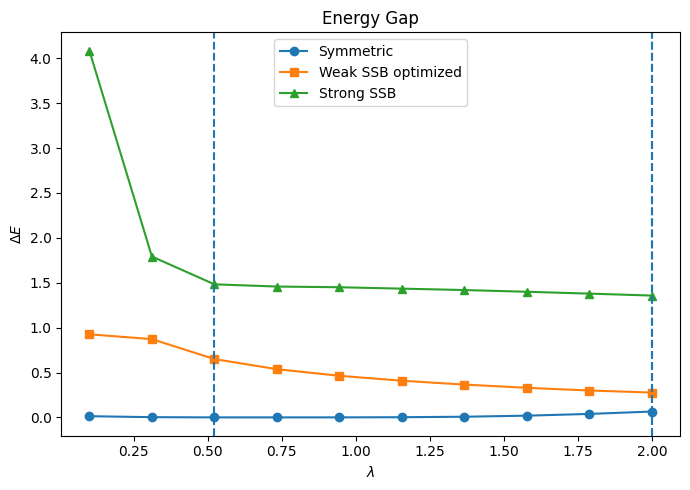

In [37]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimized')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title('Energy Gap')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    mI2 = r['mI2']

    f = r['f']
    psi_exact_final=r['psi_exact_final']
    

    M = np.real(

        np.vdot(

            psi_exact_final,

            Phi_avg @ psi_exact_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

dict_keys(['case', 'lambda', 'mI2', 'f', 'delta_min', 'final_gap', 'psi_exact_final'])


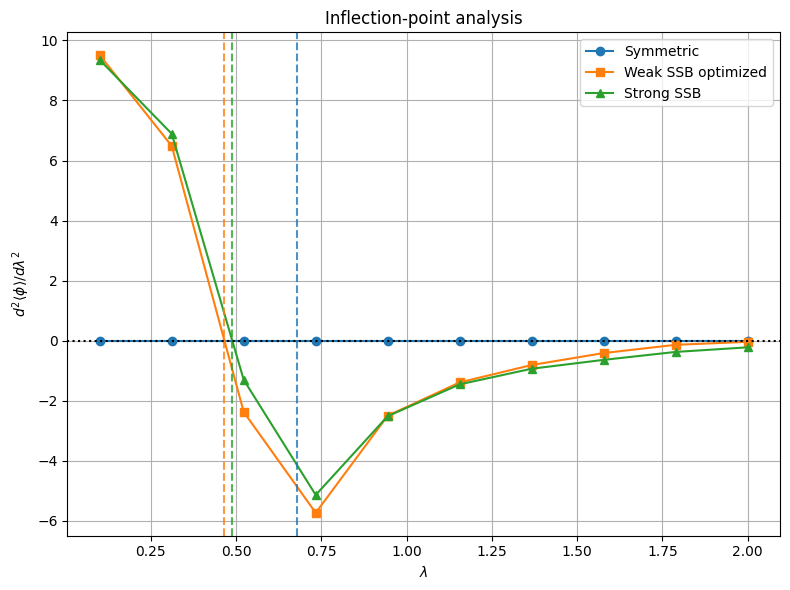

In [39]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_list)

dM_weak = np.gradient(M_weak_opt, lambda_list)

dM_strong = np.gradient(M_strong, lambda_list)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_list)

d2M_weak = np.gradient(dM_weak, lambda_list)

d2M_strong = np.gradient(dM_strong, lambda_list)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_list)

d3M_weak = np.gradient(d2M_weak, lambda_list)

d3M_strong = np.gradient(d2M_strong, lambda_list)


def find_lambda_c(lams, d2M, d3M):

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            if d3M[i] < 0:

                x1 = lams[i]
                x2 = lams[i+1]

                y1 = d2M[i]
                y2 = d2M[i+1]

                return x1 - y1*(x2-x1)/(y2-y1)

    return np.nan

lamc_M_sym = find_lambda_c(
    lambda_list,
    d2M_sym,
    d3M_sym
)

lamc_M_weak = find_lambda_c(
    lambda_list,
    d2M_weak,
    d3M_weak
)

lamc_M_strong = find_lambda_c(
    lambda_list,
    d2M_strong,
    d3M_strong
)


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

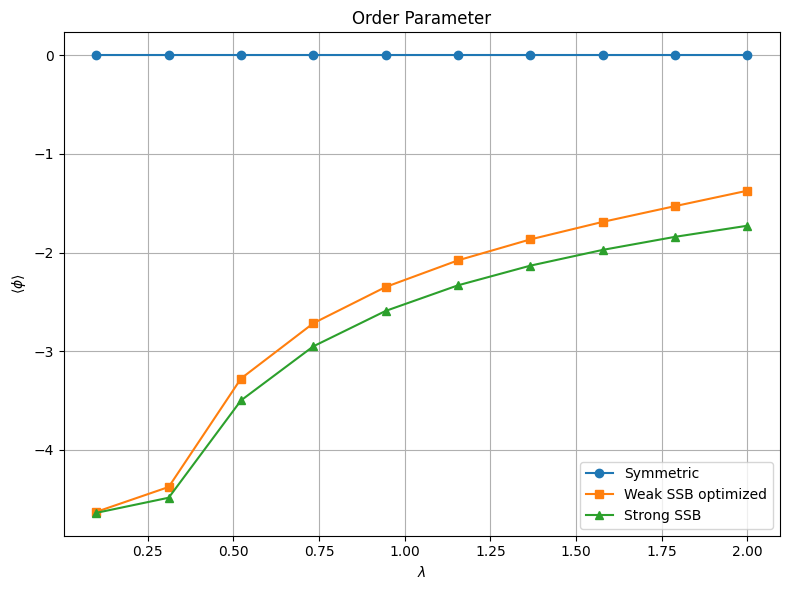

In [40]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_list,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_list,

    M_weak_opt,

    's-',

    label='Weak SSB optimized'
)

plt.plot(

    lambda_list,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title('Order Parameter')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

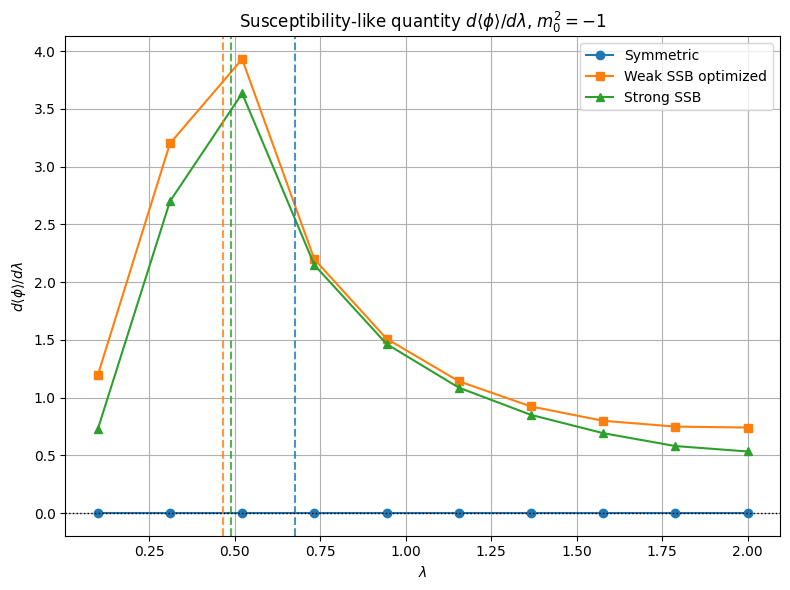

In [41]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_0^2=-1$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# m_{0}^{2}=-2

In [23]:



# ============================================================
# Storage
# ============================================================

adiabatic_results = []

# ============================================================
# MAIN LOOP
# ============================================================
for params in parameter_sets:
    for lam in lambda_list:
    
        label = params["label"]
        mI2 = params["mI2"]
        f = params["f"]
        
    
        Hs_final = two_site_hs(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=-2.0,

            lam=lam,

            f=f,

            s=1.0
        )

        E_exact_final, psi_exact_final = exact_ground_state(
        Hs_final
        )

    # ========================================================
    # Minimum gap along adiabatic path
    # ========================================================

        delta_min = minimum_gap_along_path(

            nq=nq_site,

            mu=mu,

            mI2=mI2,

            m0_sq=-2.0,

            lam=lam,

            f=f,

            nsteps=100
        )

        print(f"Minimum path gap = {delta_min:.8e}")

   

       
    
        evals, evecs = eigsh(

                Hs_final,

                k=3,

                which='SA'
            )

        idx = np.argsort(evals)

        evals = evals[idx]
        evecs = evecs[:, idx]

        psi0 = evecs[:, 0]
        psi1 = evecs[:, 1]

    
        final_gap = evals[1] - evals[0]

        print(f"E1-E0  = {final_gap:.8e}")
    

    # ========================================================
    # Store
    # ========================================================

        adiabatic_results.append({

            'case': label,
            'lambda': lam,
            'mI2': mI2,
            'f': f,

    
            'delta_min': delta_min,

        

            'final_gap': final_gap,
            'psi_exact_final': psi_exact_final
        })

   

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*180)
print("FINAL ADIABATIC SUMMARY")
print("="*180)

print(

    f"{'Case':<15}"
    f"{'lambda':<10}"
    
    f"{'Delta_min':<18}"
    
)

print("="*180)

for r in adiabatic_results:

    print(

        f"{r['case']:<15}"
        f"{r['lambda']:<10.3f}"
        
        f"{r['delta_min']:<18.8e}"
        
    )

Minimum path gap = 3.07240439e-04
E1-E0  = 1.79379555e-02
Minimum path gap = 1.17908350e-06
E1-E0  = 1.49663314e-02
Minimum path gap = 2.94880929e-07
E1-E0  = 8.14816618e-03
Minimum path gap = 1.58119085e-07
E1-E0  = 5.66132381e-05
Minimum path gap = 6.89654458e-08
E1-E0  = 1.14074849e-05
Minimum path gap = 1.17592569e-07
E1-E0  = 2.89394883e-07
Minimum path gap = 2.47961112e-07
E1-E0  = 3.11370012e-07
Minimum path gap = 3.56990568e-07
E1-E0  = 2.96441794e-07
Minimum path gap = 2.45005901e-06
E1-E0  = 1.68646320e-06
Minimum path gap = 1.44257094e-05
E1-E0  = 1.03239193e-05
Minimum path gap = 1.80997252e-02
E1-E0  = 1.79389268e-02
Minimum path gap = 1.50638569e-02
E1-E0  = 1.49674876e-02
Minimum path gap = 1.29389510e-04
E1-E0  = 8.15023181e-03
Minimum path gap = 1.10289833e-04
E1-E0  = 1.69459506e-04
Minimum path gap = 1.04207670e-04
E1-E0  = 1.39396699e-04
Minimum path gap = 1.00641152e-04
E1-E0  = 1.24417142e-04
Minimum path gap = 9.79040346e-05
E1-E0  = 1.13589115e-04
Minimum path g

In [24]:
# ============================================================
# GAP ANALYSIS
# ============================================================

from scipy.sparse.linalg import eigsh

gap_sym = []
gap_weak_opt = []
gap_strong = []

# ------------------------------------------------------------
# Symmetric
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.0,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_sym.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Weak SSB optimized
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=5*1e-2,          # optimized value
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_weak_opt.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Strong SSB
# ------------------------------------------------------------

for lam in lambda_list:

    H = two_site_hs(
        nq=nq_site,
        mu=mu,
        mI2=-1.0,
        m0_sq=-1.0,
        lam=lam,
        f=0.5,
        s=1.0
    )

    evals, _ = eigsh(H, k=2, which='SA')

    evals = np.sort(evals)

    gap_strong.append(evals[1] - evals[0])

# ------------------------------------------------------------
# Critical λ
# ------------------------------------------------------------

lamc_sym = lambda_list[np.argmin(gap_sym)]
lamc_weak = lambda_list[np.argmin(gap_weak_opt)]
lamc_strong = lambda_list[np.argmin(gap_strong)]

print("\nGap minimum estimator")
print("----------------------")
print(f"Symmetric       λc = {lamc_sym:.4f}")
print(f"Weak SSB opt    λc = {lamc_weak:.4f}")
print(f"Strong SSB      λc = {lamc_strong:.4f}")


Gap minimum estimator
----------------------
Symmetric       λc = 0.5222
Weak SSB opt    λc = 2.0000
Strong SSB      λc = 2.0000


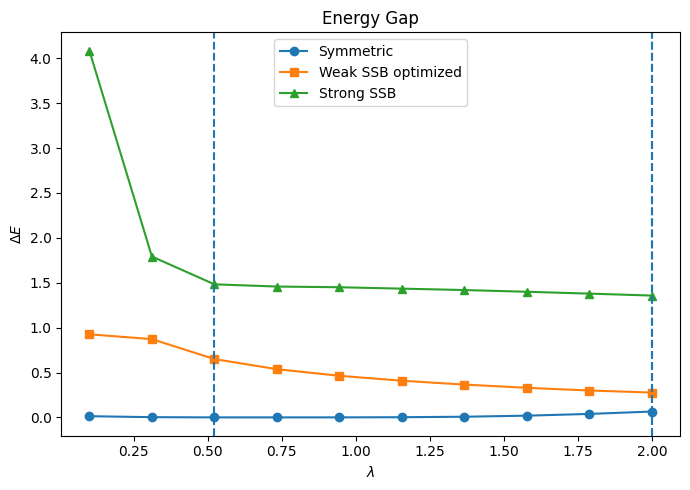

In [25]:
# ============================================================
# Plot : Gap vs lambda
# ============================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

plt.plot(lambda_list, gap_sym,
         'o-', label='Symmetric')

plt.plot(lambda_list, gap_weak_opt,
         's-', label='Weak SSB optimized')

plt.plot(lambda_list, gap_strong,
         '^-', label='Strong SSB')

plt.axvline(lamc_sym,
            ls='--')

plt.axvline(lamc_weak,
            ls='--')

plt.axvline(lamc_strong,
            ls='--')

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\Delta E$')
plt.title('Energy Gap')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
print(adiabatic_results[0].keys())

# ============================================================
# <phi> from evolved state
# ============================================================

M_sym = []

M_weak_opt = []

M_strong = []

for r in adiabatic_results:

    case = r['case']

    if case not in [

        "Symmetric",

        "Weak SSB optimised",

        "Strong SSB"
    ]:

        continue

    lam = r['lambda']

    mI2 = r['mI2']

    f = r['f']
    psi_exact_final=r['psi_exact_final']
    

    M = np.real(

        np.vdot(

            psi_exact_final,

            Phi_avg @ psi_exact_final
        )
    )

    if case == "Symmetric":

        M_sym.append(M)

    elif case == "Weak SSB optimised":

        M_weak_opt.append(M)

    elif case == "Strong SSB":

        M_strong.append(M)

dict_keys(['case', 'lambda', 'mI2', 'f', 'delta_min', 'final_gap', 'psi_exact_final'])


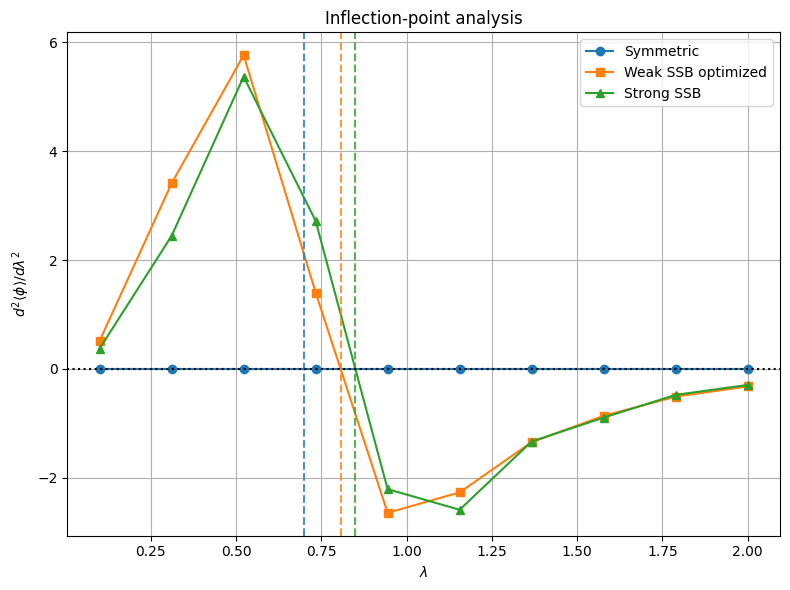

In [27]:
# ============================================================
# λc from inflection point
# ============================================================

# First derivatives

dM_sym = np.gradient(M_sym, lambda_list)

dM_weak = np.gradient(M_weak_opt, lambda_list)

dM_strong = np.gradient(M_strong, lambda_list)

# Second derivatives

d2M_sym = np.gradient(dM_sym, lambda_list)

d2M_weak = np.gradient(dM_weak, lambda_list)

d2M_strong = np.gradient(dM_strong, lambda_list)

# Third derivatives

d3M_sym = np.gradient(d2M_sym, lambda_list)

d3M_weak = np.gradient(d2M_weak, lambda_list)

d3M_strong = np.gradient(d2M_strong, lambda_list)


def find_lambda_c(lams, d2M, d3M):

    for i in range(len(lams)-1):

        if d2M[i] * d2M[i+1] <= 0:

            if d3M[i] < 0:

                x1 = lams[i]
                x2 = lams[i+1]

                y1 = d2M[i]
                y2 = d2M[i+1]

                return x1 - y1*(x2-x1)/(y2-y1)

    return np.nan

lamc_M_sym = find_lambda_c(
    lambda_list,
    d2M_sym,
    d3M_sym
)

lamc_M_weak = find_lambda_c(
    lambda_list,
    d2M_weak,
    d3M_weak
)

lamc_M_strong = find_lambda_c(
    lambda_list,
    d2M_strong,
    d3M_strong
)


########## Routine to plot d2M/d\lambda2


# ============================================================
# Plot : d²<phi>/dλ² vs λ
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    d2M_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    d2M_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    d2M_strong,
    '^-',
    label='Strong SSB'
)

# λc positions from inflection-point analysis

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

# Zero line

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1.5
)

plt.xlabel(r'$\lambda$')

plt.ylabel(
    r'$d^2\langle\phi\rangle/d\lambda^2$'
)

plt.title(
    r'Inflection-point analysis'
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

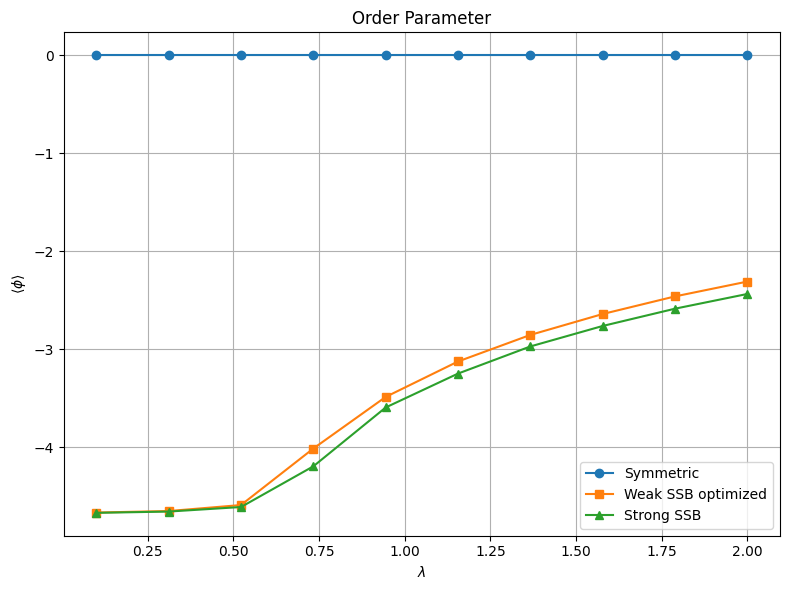

In [28]:
# ============================================================
# Plot : <phi> vs lambda
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(

    lambda_list,

    M_sym,

    'o-',

    label='Symmetric'
)

plt.plot(

    lambda_list,

    M_weak_opt,

    's-',

    label='Weak SSB optimized'
)

plt.plot(

    lambda_list,

    M_strong,

    '^-',

    label='Strong SSB'
)

plt.xlabel(r'$\lambda$')

plt.ylabel(r'$\langle \phi \rangle$')

plt.title('Order Parameter')

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

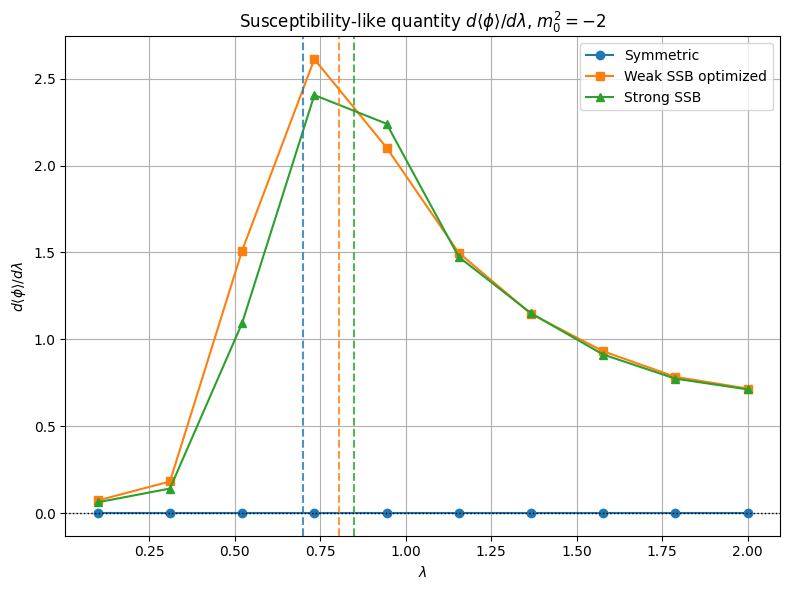

In [30]:
# ============================================================
# Plot : d<phi>/dlambda vs lambda
# ============================================================

plt.figure(figsize=(8,6))

line1, = plt.plot(
    lambda_list,
    dM_sym,
    'o-',
    label='Symmetric'
)

line2, = plt.plot(
    lambda_list,
    dM_weak,
    's-',
    label='Weak SSB optimized'
)

line3, = plt.plot(
    lambda_list,
    dM_strong,
    '^-',
    label='Strong SSB'
)

# Critical lambdas

plt.axvline(
    lamc_M_sym,
    linestyle='--',
    color=line1.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_weak,
    linestyle='--',
    color=line2.get_color(),
    alpha=0.8
)

plt.axvline(
    lamc_M_strong,
    linestyle='--',
    color=line3.get_color(),
    alpha=0.8
)

plt.axhline(
    0,
    color='k',
    linestyle=':',
    linewidth=1
)

plt.xlabel(r'$\lambda$')
plt.ylabel(r'$d\langle\phi\rangle/d\lambda$')

plt.title(
    r'Susceptibility-like quantity $d\langle\phi\rangle/d\lambda$, $m_0^2=-2$'
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()